---
# **Código elaborado por Morales Ramírez Ángel Franciso [LinkedIn](https://www.linkedin.com/in/francisco-morales-actuario/)**
---

---
# **Importación de librerías y datos**🐍
---

In [1]:
# Instalar pandasql
!pip install pandasql

In [2]:
# Importar PandaSQL
from pandasql import PandaSQL
# Crear a PandaSQL object
pandasql_query = PandaSQL()
#Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
#**Importacion de los datasets**📊
---

In [3]:
#Importación de datos
customers =pd.read_csv('https://raw.github.com/FranciscoMoralesActuary/Prueba-T-cnica-Palacio-de-Hierro/main/datos/customers.csv')
orders =pd.read_csv('https://raw.github.com/FranciscoMoralesActuary/Prueba-T-cnica-Palacio-de-Hierro/main/datos/orders.csv')
order_items =pd.read_csv('https://raw.github.com/FranciscoMoralesActuary/Prueba-T-cnica-Palacio-de-Hierro/main/datos/order_items.csv')
products =pd.read_csv('https://raw.github.com/FranciscoMoralesActuary/Prueba-T-cnica-Palacio-de-Hierro/main/datos/products.csv')

---
# **Parte 2: Python - 35 puntos - 60 minutos sugeridos🧠**
---

---
## **1. Revision Basica.**
---

---
### **I) Tamaño de los datos.**
---

In [4]:
print(f'El dataset de customers tiene {customers.shape[0]} registros y {customers.shape[1]} columnas')
print(f'El dataset de order items tiene {order_items.shape[0]:,.0f} registros y {order_items.shape[1]} columnas')
print(f'El dataset de orders tiene {orders.shape[0]:,.0f} registros y {orders.shape[1]} columnas')
print(f'El dataset de products tiene {products.shape[0]} registros y {products.shape[1]} columnas')

El dataset de customers tiene 300 registros y 4 columnas
El dataset de order items tiene 1,977 registros y 5 columnas
El dataset de orders tiene 1,372 registros y 5 columnas
El dataset de products tiene 40 registros y 4 columnas


---
### **II) Valores Nulos**
---

In [5]:
customers.isnull().sum()

,0
customer_id,0
signup_date,0
region,0
acquisition_channel,0


In [6]:
order_items.isnull().sum()

,0
order_id,0
product_id,0
quantity,0
unit_price,0
discount_pct,0


In [7]:
orders.isnull().sum()

,0
order_id,0
order_date,0
customer_id,0
channel,16
status,0


In [8]:
orders['channel'].value_counts()

,count
channel,
App,610
Web,565
Marketplace,181


In [9]:
orders[orders['channel'].isna()]

,order_id,order_date,customer_id,channel,status
5,10006,2026-01-02,150,NaN,Completada
8,10009,2026-01-03,262,NaN,Completada
76,10077,2026-01-16,55,NaN,Cancelada
98,10099,2026-01-20,8,NaN,Completada
174,10175,2026-02-01,41,NaN,Completada
197,10198,2026-02-04,144,NaN,Completada
240,10241,2026-02-11,15,NaN,Completada
244,10245,2026-02-11,222,NaN,Completada
441,10442,2026-03-10,30,NaN,Completada
561,10562,2026-03-28,2,NaN,Completada


In [10]:
products.isnull().sum()

,0
product_id,0
product_name,0
category,0
unit_price,0


---
### **III) Estadisticas.**
---

In [11]:
customers.describe(include = 'all')

,customer_id,signup_date,region,acquisition_channel
count,300.000000,300,300,300
unique,NaN,173,3,3
top,NaN,2025-08-20,Centro,Pagado
freq,NaN,7,159,124
mean,150.500000,NaN,NaN,NaN
std,86.746758,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN
25%,75.750000,NaN,NaN,NaN
50%,150.500000,NaN,NaN,NaN
75%,225.250000,NaN,NaN,NaN


In [12]:
order_items.describe(include = 'all')

,order_id,product_id,quantity,unit_price,discount_pct
count,1977.000000,1977.000000,1977.000000,1977.000000,1977.000000
mean,10683.441578,20.602428,1.256955,614.213065,0.042185
std,397.273947,11.660418,0.519589,453.619911,0.059781
min,10001.000000,1.000000,1.000000,108.360000,0.000000
25%,10338.000000,11.000000,1.000000,313.350000,0.000000
50%,10690.000000,21.000000,1.000000,517.320000,0.000000
75%,11026.000000,30.000000,1.000000,711.410000,0.100000
max,11372.000000,40.000000,3.000000,2003.110000,0.200000


In [13]:
orders.describe(include = 'all')

,order_id,order_date,customer_id,channel,status
count,1372.000000,1372,1372.000000,1356,1372
unique,NaN,181,NaN,3,3
top,NaN,2026-03-08,NaN,App,Completada
freq,NaN,13,NaN,610,1179
mean,10686.500000,NaN,147.273324,NaN,NaN
std,396.206596,NaN,88.825986,NaN,NaN
min,10001.000000,NaN,1.000000,NaN,NaN
25%,10343.750000,NaN,68.750000,NaN,NaN
50%,10686.500000,NaN,146.000000,NaN,NaN
75%,11029.250000,NaN,224.000000,NaN,NaN


In [14]:
products.describe(include = 'all')

,product_id,product_name,category,unit_price
count,40.000000,40,40,40.000000
unique,NaN,40,4,NaN
top,NaN,ELE-01,Electronica,NaN
freq,NaN,1,10,NaN
mean,20.500000,NaN,NaN,623.556000
std,11.690452,NaN,NaN,458.482729
min,1.000000,NaN,NaN,108.360000
25%,10.750000,NaN,NaN,317.220000
50%,20.500000,NaN,NaN,518.450000
75%,30.250000,NaN,NaN,719.735000


---
## **2. Tabla Semanal.**
---

In [15]:
df = pd.merge(order_items, orders, on = 'order_id', suffixes = [' itemes', ''])

In [16]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [17]:
df['ingreso_neto'] = (df['quantity'] * df['unit_price']) * (1 - df['discount_pct'])

In [18]:
df = df[df['status'] == "Completada"].copy()
df.head()

,order_id,product_id,quantity,unit_price,discount_pct,order_date,customer_id,channel,status,ingreso_neto
0,10001,17,2,639.80,0.05,2026-01-01,131,App,Completada,1215.6200
1,10001,13,1,781.66,0.10,2026-01-01,131,App,Completada,703.4940
2,10002,18,1,230.79,0.05,2026-01-01,34,App,Completada,219.2505
3,10003,30,1,320.39,0.00,2026-01-01,30,Web,Completada,320.3900
6,10005,3,1,744.71,0.05,2026-01-02,157,Web,Completada,707.4745


In [19]:
df_semanal = df.groupby(pd.Grouper(key = 'order_date', freq =  'W')).agg(ingreso_neto = ('ingreso_neto', 'sum'), ordenes_completadas = ('order_id', 'nunique')).reset_index()
df_semanal['ticket_promedio'] = df_semanal['ingreso_neto'] / df_semanal['ordenes_completadas']
df_semanal

,order_date,ingreso_neto,ordenes_completadas,ticket_promedio
0,2026-01-04,25333.5250,24,1055.563542
1,2026-01-11,36259.7465,33,1098.780197
2,2026-01-18,26055.2845,22,1184.331114
3,2026-01-25,57166.7495,43,1329.459291
4,2026-02-01,29178.6985,32,911.834328
5,2026-02-08,47549.1760,41,1159.736000
6,2026-02-15,53232.1660,41,1298.345512
7,2026-02-22,48372.5615,39,1240.322090
8,2026-03-01,58144.8475,44,1321.473807
9,2026-03-08,56323.6125,56,1005.778795


---
## **3. Semanas con disminucion del ingreso neto.**
---

In [20]:
df_semanal['ingreso_neto anterior'] = df_semanal['ingreso_neto'].shift(1)

In [21]:
df_semanal['Disminucion'] = np.where(df_semanal['ingreso_neto'] < df_semanal['ingreso_neto anterior'] * 0.85, 1, 0)

In [22]:
df_semanal['% Disminucion'] = (df_semanal['ingreso_neto'] / df_semanal['ingreso_neto anterior']) - 1

In [23]:
df_semanal

,order_date,ingreso_neto,ordenes_completadas,ticket_promedio,ingreso_neto anterior,Disminucion,% Disminucion
0,2026-01-04,25333.5250,24,1055.563542,NaN,0,NaN
1,2026-01-11,36259.7465,33,1098.780197,25333.5250,0,0.431295
2,2026-01-18,26055.2845,22,1184.331114,36259.7465,1,-0.281427
3,2026-01-25,57166.7495,43,1329.459291,26055.2845,0,1.194056
4,2026-02-01,29178.6985,32,911.834328,57166.7495,1,-0.489586
5,2026-02-08,47549.1760,41,1159.736000,29178.6985,0,0.629585
6,2026-02-15,53232.1660,41,1298.345512,47549.1760,0,0.119518
7,2026-02-22,48372.5615,39,1240.322090,53232.1660,0,-0.091291
8,2026-03-01,58144.8475,44,1321.473807,48372.5615,0,0.202021
9,2026-03-08,56323.6125,56,1005.778795,58144.8475,0,-0.031322


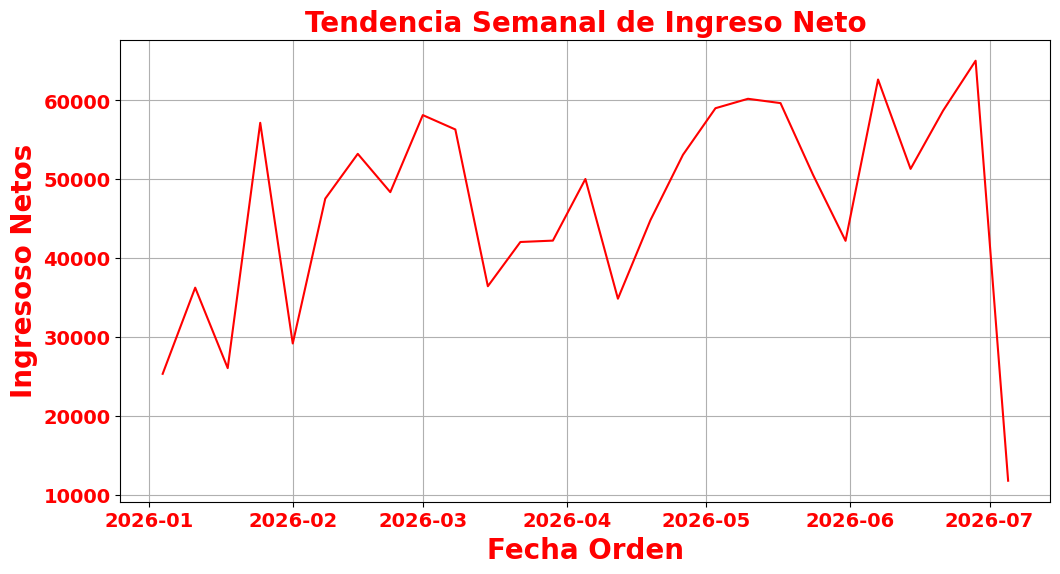

In [24]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_semanal, x='order_date', y='ingreso_neto', color='red')
plt.title('Tendencia Semanal de Ingreso Neto',
          fontsize = 20,
          color = 'red',fontweight='bold')

plt.xlabel('Fecha Orden',fontsize = 20,
           color = 'red',fontweight='bold')

plt.ylabel('Ingresoso Netos',fontsize = 20,
           color = 'red',fontweight='bold')

plt.xticks(fontsize=14, color='red',fontweight='bold')
plt.yticks(fontsize=14, color='red',fontweight='bold')
plt.grid(True)
plt.show()

---
## **4) Segmentación util de clientes**
---

Se busca segmentar a los clientes por patrones de las órdenes canceladas y devueltas, analizaremos su distribución por región de cliente y por producto.

In [25]:
# Ordenes canceladas o devueltas
segmentacion = orders[orders['status'].isin(['Cancelada', 'Devuelta'])]

# Segmentación por Región
region = pd.merge(segmentacion, customers, on='customer_id', how='inner')
print("\nÓrdenes Canceladas/Devueltas por Región:")
display(region['region'].value_counts())

# Segmentación por Producto
producto = pd.merge(segmentacion, order_items, on='order_id', how='inner')
cancelled_returned_products_details = pd.merge(producto, products, on='product_id', how='inner')
print("\nTop 5 Productos más Cancelados/Devueltos:")
display(cancelled_returned_products_details['product_name'].value_counts().head(5))


Órdenes Canceladas/Devueltas por Región:


,count
region,
Centro,105
Norte,47
Sur,41



Top 5 Productos más Cancelados/Devueltos:


,count
product_name,
HOG-07,13
ELE-06,12
BEL-04,11
DEP-04,11
DEP-01,10


### **Uso de Negocio Simple:**

Identificar qué regiones tienen más cancelaciones/devoluciones puede indicar problemas de logística locales o expectativas de cliente diferentes. Saber qué productos se devuelven más puede señalar problemas de calidad, descripciones poco claras o que el producto no satisface la necesidad real del cliente. Con esta información, la empresa puede enfocar sus esfuerzos en mejorar procesos o productos específicos para reducir estas incidencias.